# Controlling Locomotion with CPGs

**Authors:** Sibo Wang-Chen, Femke Hurtak, Thomas Ka Chung Lam

**Summary:** In this tutorial, we build a Central Pattern Generator (CPG) network and use it to control walking of the simulated fly. The code has been simplified for presentation in a notebook; a more complete implementation can be found in the [examples folder of the FlyGym repository](https://github.com/NeLy-EPFL/flygym/tree/main/flygym/examples/).

Central Pattern Generators (CPGs) are neural circuits that produce rhythmic output without requiring rhythmic input (see review by [Mantziaris et al., 2020](https://doi.org/10.1002/dneu.22738)). They play a crucial role in locomotion across species, and their principles have been widely adopted in robotic motor control ([Ijspeert, 2008](https://doi.org/10.1016/j.neunet.2008.03.014)). It is hypothesized that CPGs play a more important role in fast-moving animals that cannot process decentralized sensory signals in time to adjust their movements (e.g., cockroaches running at ~1 m/s).

In this tutorial, we will:
1. Implement an oscillator network.
2. Map oscillator phases to preprogrammed leg-stepping kinematics.
3. Plug the controller into NeuroMechFly for physics simulation.
4. Add leg adhesion to the locomotor simulation.

## The CPG network

Basic CPGs can be implemented as feedforward networks of oscillators—in other words, the network behaves without taking into account sensory feedback. Similar to the formulation from [Ijspeert et al (2007)](https://doi.org/10.1126/science.1138353), the oscillator network can be described by the following ordinary differential equations (ODEs):
$$ \dot\theta_i = 2\pi\nu_i + \sum_{j} r_j w_{ij} \sin(\theta_j - \theta_i - \phi_{ij}) $$
$$ \dot r_i = \alpha_i (R_i - r_i) $$
where $\theta_i$ and $r_i$ are the current phase and magnitude of the i-th oscillator. $R_i$ is the maximum amplitude of the i-th oscillator, and $\alpha_i$ is a constant determining the rate of convergence to synchrony. $w_{ij}$ is the coupling weight between the i-th and the j-th oscillator, and $\phi_{ij}$ is the phase bias between them. Intuitively, the first term of the first equation maintains an intrinsic frequency for each oscillator; the second term of the first equation keeps the oscillators synchronized (i.e., maintains the phase differences between the oscillators), and the second equation maintains the amplitudes of the oscillators.

Let's implement this system. We write a function that computes $\dot\theta$ and $\dot r$ using only Python and NumPy:

In [1]:
import numpy as np


def calculate_ddt(theta, r, w, phi, nu, R, alpha):
    """Given the current state variables theta, r and network parameters
    w, phi, nu, R, alpha, calculate the time derivatives of theta and r."""
    intrinsic_term = 2 * np.pi * nu
    phase_diff = theta[np.newaxis, :] - theta[:, np.newaxis]
    coupling_term = (r * w * np.sin(phase_diff - phi)).sum(axis=1)
    dtheta_dt = intrinsic_term + coupling_term
    dr_dt = alpha * (R - r)
    return dtheta_dt, dr_dt

Next, we wrap the ODE into a class and integrate it with [Euler's method](https://en.wikipedia.org/wiki/Euler_method). You could equally use a higher-order integrator or `scipy.integrate`.

In [2]:
class CPGNetwork:
    def __init__(
        self,
        timestep,
        intrinsic_freqs,
        intrinsic_amps,
        coupling_weights,
        phase_biases,
        convergence_coefs,
        init_phases=None,
        init_magnitudes=None,
        seed=0,
    ) -> None:
        """Initialize a CPG network consisting of N oscillators.

        Parameters
        ----------
        timestep : float
            The timestep of the simulation.
        intrinsic_freqs : np.ndarray
            The intrinsic frequencies of the oscillators, shape (N,).
        intrinsic_amps : np.ndarray
            The intrinsic amplitude of the oscillators, shape (N,).
        coupling_weights : np.ndarray
            The coupling weights between the oscillators, shape (N, N).
        phase_biases : np.ndarray
            The phase biases between the oscillators, shape (N, N).
        convergence_coefs : np.ndarray
            Coefficients describing the rate of convergence to oscillator
            intrinsic amplitudes, shape (N,).
        init_phases : np.ndarray, optional
            Initial phases of the oscillators, shape (N,). The phases are
            randomly initialized if not provided.
        init_magnitudes : np.ndarray, optional
            Initial magnitudes of the oscillators, shape (N,). The
            magnitudes are randomly initialized if not provided.
        seed : int, optional
            The random seed to use for initializing the phases and
            magnitudes.
        """
        self.timestep = timestep
        self.num_cpgs = intrinsic_freqs.size
        self.intrinsic_freqs = intrinsic_freqs
        self.intrinsic_amps = intrinsic_amps
        self.coupling_weights = coupling_weights
        self.phase_biases = phase_biases
        self.convergence_coefs = convergence_coefs
        self.seed = seed

        self.reset(init_phases, init_magnitudes)

        # Check if the parameters have the right shape
        assert intrinsic_freqs.shape == (self.num_cpgs,)
        assert coupling_weights.shape == (self.num_cpgs, self.num_cpgs)
        assert phase_biases.shape == (self.num_cpgs, self.num_cpgs)
        assert convergence_coefs.shape == (self.num_cpgs,)
        assert self.curr_phases.shape == (self.num_cpgs,)
        assert self.curr_magnitudes.shape == (self.num_cpgs,)

    def step(self):
        """Integrate the ODEs using Euler's method."""
        dtheta_dt, dr_dt = calculate_ddt(
            theta=self.curr_phases,
            r=self.curr_magnitudes,
            w=self.coupling_weights,
            phi=self.phase_biases,
            nu=self.intrinsic_freqs,
            R=self.intrinsic_amps,
            alpha=self.convergence_coefs,
        )
        self.curr_phases += dtheta_dt * self.timestep
        self.curr_magnitudes += dr_dt * self.timestep

    def reset(self, init_phases=None, init_magnitudes=None):
        """Reset the phases and magnitudes of the oscillators.
        High magnitudes and unfortunate phases might cause physics error
        """
        if init_phases is None:
            rng = np.random.default_rng(seed=self.seed)
            self.curr_phases = rng.random(self.num_cpgs) * 2 * np.pi
        else:
            self.curr_phases = init_phases

        if init_magnitudes is None:
            self.curr_magnitudes = np.zeros(self.num_cpgs)
        else:
            self.curr_magnitudes = init_magnitudes

To demonstrate this network, let's simulate a network of three oscillators connected as follows:

<img src="https://raw.githubusercontent.com/NeLy-EPFL/_media/main/flygym/cpg_controller/simple_cpg.png" alt="simple_cpg" width="500"/>

For the sake of illustration, let's make them oscillate at an intrinsic frequency of 1 and intrinsic amplitudes of 1.0, 1.1, 1.2. They are coupled with a weight of 1 and phase differences of 120 degrees. We will initialize the phases randomly.

In [3]:
intrinsic_freqs = np.ones(3)
intrinsic_amps = np.array([1.0, 1.1, 1.2])
coupling_weights = np.array(
    [
        [0, 1, 0],
        [1, 0, 1],
        [0, 1, 0],
    ]
)
phase_biases = np.deg2rad(
    np.array(
        [
            [0, 120, 0],
            [-120, 0, 120],
            [0, -120, 0],
        ]
    )
)
convergence_coefs = np.ones(3)

network = CPGNetwork(
    timestep=1e-3,
    intrinsic_freqs=intrinsic_freqs,
    intrinsic_amps=intrinsic_amps,
    coupling_weights=coupling_weights,
    phase_biases=phase_biases,
    convergence_coefs=convergence_coefs,
)

num_steps = int(10 / network.timestep)
phase_hist = np.empty((num_steps, 3))
magnitude_hist = np.empty((num_steps, 3))

# Simulate the network
for i in range(num_steps):
    network.step()
    phase_hist[i, :] = network.curr_phases
    magnitude_hist[i, :] = network.curr_magnitudes

The phases converge to steady offsets of $2\pi/3$ (120°) as expected, and the magnitudes settle at their intrinsic values (1.0, 1.1, 1.2) after a brief transient.

Text(0.5, 0, 'Time (s)')

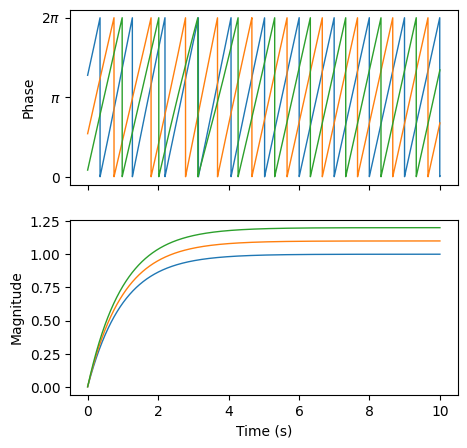

In [4]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
t = np.arange(num_steps) * network.timestep
axs[0].plot(t, phase_hist % (2 * np.pi), linewidth=1)
axs[0].set_yticks([0, np.pi, 2 * np.pi])
axs[0].set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
axs[0].set_ylabel("Phase")
axs[1].plot(t, magnitude_hist, linewidth=1)
axs[1].set_ylabel("Magnitude")
axs[1].set_xlabel("Time (s)")

We have a working CPG network. Next, we address how the oscillator states drive actual leg movements.

## Controlling leg stepping with CPGs

The CPG state variables $\theta$ and $r$ can drive locomotion at various levels of abstraction — from directly setting motor neuron activity ([Lobato-Rios et al., 2022](https://doi.org/10.1038/s41592-022-01466-7)) to controlling target joint positions ([Ijspeert et al., 2007](https://doi.org/10.1126/science.1138353)).

Here, we adopt an even higher-level approach: **each oscillator controls the stepping of an entire leg.** The oscillator phase $\theta_i$ determines *where* in the step cycle leg $i$ is, and the magnitude $r_i$ scales *how large* the step is. We extract a single-step kinematic template from experimental recordings and modulate it by $\theta$ and $r$.

### Tripod gait coupling

We configure the network for a **tripod gait**: at any point in time, the front and hind legs on one side plus the mid leg on the other side form a stance tripod, while the remaining three legs swing. Legs that should *not* swing together are coupled with a phase bias of $\pi$ (180°), ensuring they alternate.

<img src="https://raw.githubusercontent.com/NeLy-EPFL/_media/main/flygym/cpg_controller/tripod_cpg.png" alt="tripod_cpg" width="600"/>

Let's set up this 6-oscillator network, simulate it, and plot the state variables:

Text(0.5, 0, 'Time (s)')

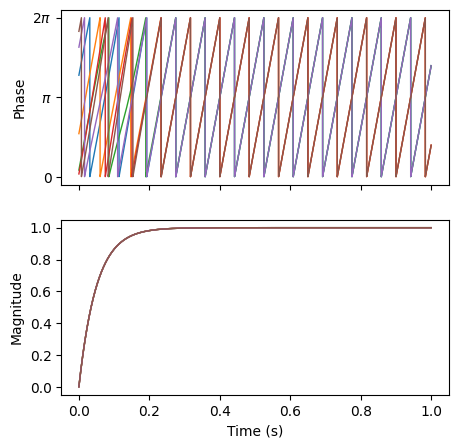

In [5]:
# --- Tripod gait parameters ---
intrinsic_freqs = np.ones(6) * 12
intrinsic_amps = np.ones(6) * 1
phase_biases = np.pi * np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
)
coupling_weights = (phase_biases > 0).astype(float) * 10
convergence_coefs = np.ones(6) * 20

tripod_network = CPGNetwork(
    timestep=1e-4,
    intrinsic_freqs=intrinsic_freqs,
    intrinsic_amps=intrinsic_amps,
    coupling_weights=coupling_weights,
    phase_biases=phase_biases,
    convergence_coefs=convergence_coefs,
)

# Simulate for 1 second
num_steps = int(1 / tripod_network.timestep)
phase_hist = np.empty((num_steps, 6))
magnitude_hist = np.empty((num_steps, 6))
for i in range(num_steps):
    tripod_network.step()
    phase_hist[i] = tripod_network.curr_phases
    magnitude_hist[i] = tripod_network.curr_magnitudes

# Plot
fig, axs = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
t = np.arange(num_steps) * tripod_network.timestep
axs[0].plot(t, phase_hist % (2 * np.pi), linewidth=1)
axs[0].set_yticks([0, np.pi, 2 * np.pi])
axs[0].set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
axs[0].set_ylabel("Phase")
axs[1].plot(t, magnitude_hist, linewidth=1)
axs[1].set_ylabel("Magnitude")
axs[1].set_xlabel("Time (s)")

Now let's load the preprogrammed single-step kinematics:

In [6]:
from flygym import assets_dir

single_steps_path = assets_dir / "demo" / "single_steps_untethered.npz"
single_steps_data = np.load(single_steps_path, allow_pickle=True)

dof_angles = single_steps_data["dof_angles"]  # (n_frames, n_dofs)
dof_names = [str(s) for s in single_steps_data["dof_order"]]
data_n_frames = dof_angles.shape[0]
data_timestep = single_steps_data["timestep"].item()
swing_time = single_steps_data["swing_time"].item()  # dict: leg → seconds
stance_time = single_steps_data["stance_time"].item()  # dict: leg → seconds

For each leg $i$, we build a function $\Psi_i$ that maps the current stepping phase $\theta_i$ to the joint angles of all DoFs on that leg. We do this by fitting a periodic cubic spline to the preprogrammed kinematics:

In [7]:
from scipy.interpolate import CubicSpline

# Leg abbreviations: l/r = left/right, f/m/h = front/middle/hind
legs = [f"{side}{pos}" for side in "lr" for pos in "fmh"]

# DoF name templates for each leg (7 DoFs per leg)
dofs_per_leg = [
    "c_thorax-{leg}_coxa-yaw",
    "c_thorax-{leg}_coxa-pitch",
    "c_thorax-{leg}_coxa-roll",
    "{leg}_coxa-{leg}_trochanterfemur-pitch",
    "{leg}_coxa-{leg}_trochanterfemur-roll",
    "{leg}_trochanterfemur-{leg}_tibia-pitch",
    "{leg}_tibia-{leg}_tarsus1-pitch",
]

# Build a periodic cubic spline for each leg: phase ∈ [0, 2π] → joint angles
phase_grid = np.linspace(0, 2 * np.pi, data_n_frames)
psi_funcs = {}
for leg in legs:
    col_idx = [dof_names.index(dof.format(leg=leg)) for dof in dofs_per_leg]
    psi_funcs[leg] = CubicSpline(
        x=phase_grid,
        y=dof_angles[:, col_idx],
        axis=0,
        bc_type="periodic",
    )

Let's visualise three complete stepping cycles for each leg — the periodic spline produces smooth, tileable motion:

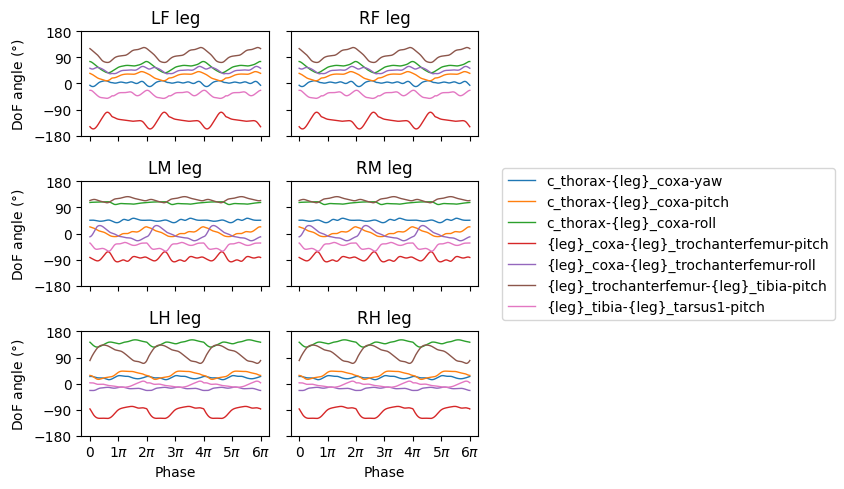

In [8]:
theta_ts = np.linspace(0, 3 * 2 * np.pi, 10_000)

fig, axs = plt.subplots(3, 2, figsize=(5, 5), sharex=True, sharey=True)
for i_side, side in enumerate("lr"):
    for i_pos, pos in enumerate("fmh"):
        leg = f"{side}{pos}"
        ax = axs[i_pos, i_side]
        joint_angles = np.rad2deg(psi_funcs[leg](theta_ts))
        for i_dof, dof_tmpl in enumerate(dofs_per_leg):
            label = dof_tmpl if (i_pos == 0 and i_side == 0) else None
            ax.plot(theta_ts, joint_angles[:, i_dof], linewidth=1, label=label)
        if i_pos == 2:
            ax.set_xlabel("Phase")
            ax.set_xticks(np.pi * np.arange(7))
            ax.set_xticklabels(["0"] + [rf"{x}$\pi$" for x in range(1, 7)])
        if i_side == 0:
            ax.set_ylabel(r"DoF angle ($\degree$)")
        ax.set_title(f"{leg.upper()} leg")
        ax.set_ylim(-180, 180)
        ax.set_yticks([-180, -90, 0, 90, 180])
fig.legend(loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()

### Amplitude modulation

We can modulate the step size using the CPG magnitude $r$. We take the difference between the joint angles and a neutral (rest) position, then scale by $r$:

$$\text{output} = \Psi_0 + r \cdot (\Psi(\theta) - \Psi_0)$$

where $\Psi_0$ is the pose at the beginning of the preprogrammed step. Let's visualise this by ramping $r$ from 0 to 1 over three cycles:

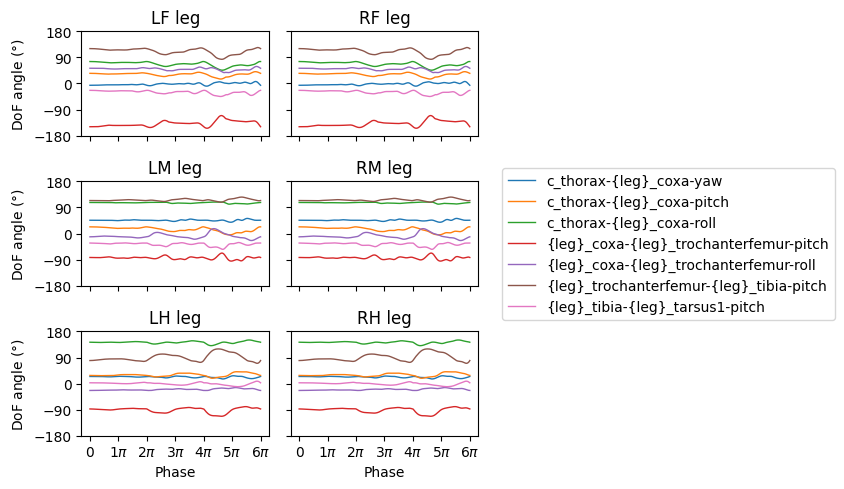

In [9]:
theta_ts = np.linspace(0, 3 * 2 * np.pi, 10_000)
r_ts = np.linspace(0, 1, 10_000)

fig, axs = plt.subplots(3, 2, figsize=(5, 5), sharex=True, sharey=True)
for i_side, side in enumerate("lr"):
    for i_pos, pos in enumerate("fmh"):
        leg = f"{side}{pos}"
        ax = axs[i_pos, i_side]
        neutral_pos = psi_funcs[leg](0)
        modulated = neutral_pos + r_ts[:, None] * (
            psi_funcs[leg](theta_ts) - neutral_pos
        )
        joint_angles = np.rad2deg(modulated)
        for i_dof, dof_tmpl in enumerate(dofs_per_leg):
            label = dof_tmpl if (i_pos == 0 and i_side == 0) else None
            ax.plot(theta_ts, joint_angles[:, i_dof], linewidth=1, label=label)
        if i_pos == 2:
            ax.set_xlabel("Phase")
            ax.set_xticks(np.pi * np.arange(7))
            ax.set_xticklabels(["0"] + [rf"{x}$\pi$" for x in range(1, 7)])
        if i_side == 0:
            ax.set_ylabel(r"DoF angle ($\degree$)")
        ax.set_title(f"{leg.upper()} leg")
        ax.set_ylim(-180, 180)
        ax.set_yticks([-180, -90, 0, 90, 180])
fig.legend(loc="center left", bbox_to_anchor=(1, 0.5))
fig.tight_layout()

We have now built the two key elements of the controller:

- **Inter-leg coordination:** the CPG network controls the phase $\theta$ and stepping magnitude $r$ of each leg.
- **Per-leg kinematics:** the function $\Psi(\theta)$ maps CPG phase to joint angles (from experimental data), scaled by $r$.

In the next section, we piece these components together and run the physics simulation.

## Plugging the controller into the simulation

We now put everything together and control the simulated fly using our CPG-based controller. This section assumes familiarity with the [kinematic replay tutorial](kinematic_replay.ipynb) from Week 1.

First, we convert the swing/stance timing from seconds to phase (radians) and define a "rest phase" — the neutral position used for amplitude modulation (midpoint between the end of swing and the start of the next swing):

In [10]:
# Convert swing/stance start times from seconds to phase (radians)
step_duration = data_n_frames * data_timestep
swing_start_phase = (
    np.array([swing_time[leg] for leg in legs]) / step_duration * (2 * np.pi)
)
swing_end_phase = (
    np.array([stance_time[leg] for leg in legs]) / step_duration * (2 * np.pi)
)

# Rest phase: midpoint between end-of-swing and start of next swing cycle.
# This is the neutral position used for amplitude modulation.
rest_phases = (swing_end_phase + 2 * np.pi) / 2

# Build the DoF name list (ordered by leg, then by DoF within leg)
dof_order = [dof.format(leg=leg) for leg in legs for dof in dofs_per_leg]

Now we initialise a CPG network for the simulation (with a high convergence coefficient so the oscillators lock in quickly) and generate the joint-angle trajectory:

At each timestep, we advance the CPG, look up the joint angles at the current phase, and modulate them by the current magnitude $r$. The final joint positions are $\Psi_0 + r \cdot (\Psi(\theta) - \Psi_0)$, where $\Psi_0$ is the rest (neutral) pose:

In [11]:
run_time = 1.0
timestep = 1e-4

# Re-create network with high convergence for quick lock-in
cpg_network = CPGNetwork(
    timestep=timestep,
    intrinsic_freqs=intrinsic_freqs,
    intrinsic_amps=intrinsic_amps,
    coupling_weights=coupling_weights,
    phase_biases=phase_biases,
    convergence_coefs=np.ones(6) * 1000,
    seed=1,
)

n_steps = int(run_time / timestep)
joint_angles = np.zeros((n_steps, len(legs), len(dofs_per_leg)))

for i in range(n_steps):
    cpg_network.step()
    for j, leg in enumerate(legs):
        psi = psi_funcs[leg](cpg_network.curr_phases[j])
        psi_rest = psi_funcs[leg](rest_phases[j])
        joint_angles[i, j] = (
            psi_rest + (psi - psi_rest) * cpg_network.curr_magnitudes[j]
        )

joint_angles_flat = joint_angles.reshape((n_steps, -1))

In [12]:
from utils import run_simulation, show_video

sim, _ = run_simulation(
    dof_angles=joint_angles_flat, dof_names=dof_order, warmup_steps=0
)

100%|██████████| 10000/10000 [00:31<00:00, 318.16it/s]


In [13]:
show_video(sim, title="CPG control")

CPG control This browser does not support the video tag.


## Leg adhesion

Insects have evolved adhesive structures that generate substantial normal forces (10–100× body weight) allowing them to navigate complex 3D terrain. Because we cannot fully model real biological adhesion, we approximate it by injecting an additional normal force into the pretarsus of each leg when it contacts a substrate.

Despite the large adhesion forces, insects can still lift their legs seemingly without effort. The mechanisms are not well understood in *Drosophila*, so we abstract them: **adhesion is on during stance and off during swing.** The preprogrammed stepping data includes swing and stance onset times (in seconds):

In [14]:
swing_start_phase, swing_end_phase

(array([0., 0., 0., 0., 0., 0.]),
 array([2.37364778, 2.23402144, 1.95476876, 2.37364778, 2.23402144,
        1.95476876]))

Let's write a function that, given the phases of the legs, return a boolean mask indicating whether adhesion should be on (during stance) or off (during swing):

In [15]:
def get_adhesion_onoff(theta):
    """Return True (adhesion on) during stance, False during swing."""
    theta = theta % (2 * np.pi)
    return ~((theta > swing_start_phase) & (theta < swing_end_phase)).squeeze()

To illustrate this binary signal (low = off, during swing; high = on, during stance):

Text(0, 0.5, 'Adhesion on/off')

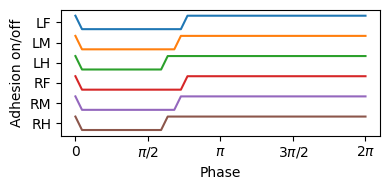

In [16]:
onoff_signal = np.zeros((6, phase_grid.size), dtype=bool)
for i in range(phase_grid.size):
    onoff_signal[:, i] = get_adhesion_onoff(phase_grid[i])

fig, ax = plt.subplots(figsize=(4, 2), tight_layout=True)
for i in range(6):
    ax.plot(phase_grid, onoff_signal[i, :] - i * 1.5)
ax.set_yticks(-np.arange(6) * 1.5 + 0.5)
ax.set_yticklabels([s.upper() for s in legs])
ax.set_xticks(np.arange(5) * np.pi / 2)
ax.set_xticklabels(["0", r"$\pi/2$", r"$\pi$", r"3$\pi$/2", r"$2\pi$"])
ax.set_xlabel("Phase")
ax.set_ylabel("Adhesion on/off")

Now we regenerate the trajectory — this time also computing the per-step adhesion signal — and re-run the simulation with adhesion enabled:

In [17]:
cpg_network.reset()

n_steps = int(run_time / timestep)
joint_angles = np.zeros((n_steps, len(legs), len(dofs_per_leg)))
adhesion_signals = np.zeros((n_steps, len(legs)))

for i in range(n_steps):
    cpg_network.step()
    for j, leg in enumerate(legs):
        psi = psi_funcs[leg](cpg_network.curr_phases[j])
        psi_rest = psi_funcs[leg](rest_phases[j])
        joint_angles[i, j] = (
            psi_rest + (psi - psi_rest) * cpg_network.curr_magnitudes[j]
        )
    adhesion_signals[i] = get_adhesion_onoff(cpg_network.curr_phases)

joint_angles_flat = joint_angles.reshape((n_steps, -1))

In [18]:
adhesion_segments = [f"{leg}_tarsus5" for leg in legs]

sim, _ = run_simulation(
    dof_angles=joint_angles_flat,
    dof_names=dof_order,
    adhesion_segments=adhesion_segments,
    adhesion_signals=adhesion_signals,
    adhesion_gain=100,
    warmup_steps=0,
)

100%|██████████| 10000/10000 [00:33<00:00, 300.09it/s]


In [20]:
show_video(sim, title="CPG control + adhesion")

CPG control + adhesion This browser does not support the video tag.
